In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv(r"C:\Users\USER\Desktop\PROject\spotify\DATA\clean_spotify_data.csv")

In [11]:
df

,artists,track_name,track_genre,danceability,energy,key,loudness,acousticness,instrumentalness,liveness,valence,tempo
0,10357,11741,0,0.629244,-0.717148,-1.210442,0.300828,-0.850202,-0.504109,0.758743,0.929306,-1.141863
1,3287,22528,0,-0.845908,-1.889980,-1.210442,-1.784744,1.831732,-0.504094,-0.591211,-0.798690,-1.489717
2,12397,60774,0,-0.742186,-1.122669,-1.491343,-0.293288,-0.315499,-0.504112,-0.507167,-1.365688,-1.528312
3,14839,9580,0,-1.733304,-2.312994,-1.491343,-2.039252,1.774593,-0.503883,-0.428376,-1.276974,1.987859
4,5255,25689,0,0.295030,-0.788711,-0.929541,-0.282750,0.463399,-0.504112,-0.686285,-1.184403,-0.073348
...,...,...,...,...,...,...,...,...,...,...,...,...
113995,22486,53329,113,-2.274962,-1.615656,-0.086838,-1.617326,0.977652,2.493755,-0.668426,-1.697787,0.128333
113996,22486,65090,113,-2.263437,-2.084789,-1.491343,-2.000082,2.042245,2.648817,-0.570200,-1.693545,-1.231195
113997,4952,38207,113,0.358416,-1.241940,-1.491343,-0.524135,1.660315,-0.504112,-0.681033,1.037306,0.341255
113998,18534,21507,113,0.116398,-0.538241,0.474964,-0.522942,0.198754,-0.504112,0.296502,-0.235548,0.460742


C:\Users\USER\AppData\Local\Temp\ipykernel_2612\3841831752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette="viridis")


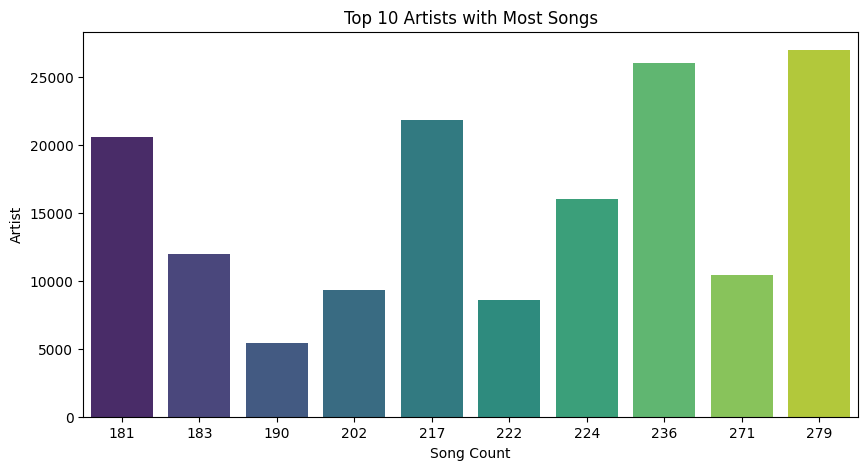

In [12]:

top_artists = df['artists'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_artists.values, y=top_artists.index, palette="viridis")
plt.title("Top 10 Artists with Most Songs")
plt.xlabel("Song Count")
plt.ylabel("Artist")
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_2612\1650816481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="magma")


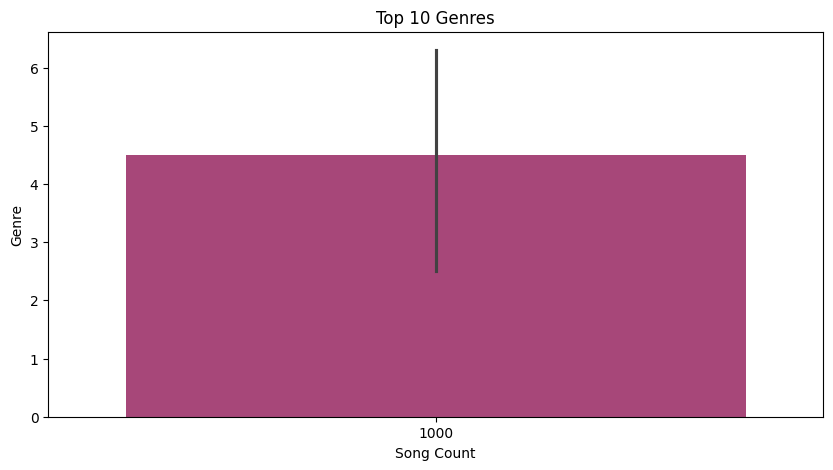

In [13]:
top_genres = df['track_genre'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="magma")
plt.title("Top 10 Genres")
plt.xlabel("Song Count")
plt.ylabel("Genre")
plt.show()

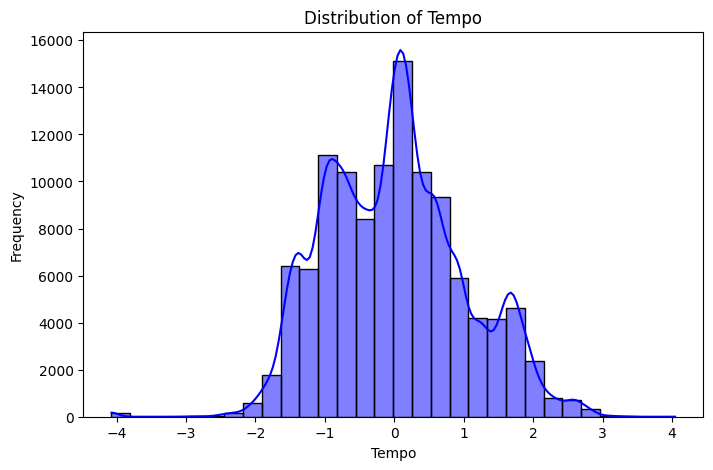

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['tempo'], bins=30, kde=True, color="blue")
plt.title("Distribution of Tempo")
plt.xlabel("Tempo")
plt.ylabel("Frequency")
plt.show()

In [1]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

feature_cols = [c for c in ["danceability","energy","valence","tempo","acousticness",
                            "liveness","instrumentalness","loudness","speechiness"]
                if c in df.columns]
X = df[feature_cols].values

# Fit kNN on features
knn = NearestNeighbors(n_neighbors=11, metric="cosine")  # 1 is the song itself + 10 neighbors
knn.fit(X)

def find_track_index(query_track, query_artist=None):
    q = query_track.strip().lower()
    if query_artist:
        mask = (df["track_name"].str.lower()==q) & (df["artist_name"].str.lower()==query_artist.strip().lower())
    else:
        mask = (df["track_name"].str.lower()==q)
    matches = df[mask]
    if matches.empty:
        # fallback: contains (simple)
        matches = df[df["track_name"].str.lower().str.contains(q)]
    return matches.index[0] if not matches.empty else None

def recommend_content_based(track_name, artist_name=None, k=5):
    idx = find_track_index(track_name, artist_name)
    if idx is None:
        return []
    distances, indices = knn.kneighbors(X[idx].reshape(1,-1), n_neighbors=k+1)
    # skip self (first result)
    rec_idx = [i for i in indices.flatten() if i!=idx][:k]
    return df.iloc[rec_idx][["track_name","artist_name"]].to_dict(orient="records")


NameError: name 'df' is not defined

In [16]:
recommend_content_based("Blinding Lights", "The Weeknd", k=5)

AttributeError: Can only use .str accessor with string values!